In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from kagome_order_diagnosis import KagomeOrderDiagnoser

from frg_flow import BareVertexFromInteraction
from frg_flow import FRGFlowSolver

# Model and Patch

In [2]:
# -----------------------------
# physical parameters
# -----------------------------
t = 1.0
phi = 0.0          # real hopping only
filling = 5.0 / 12.0
U = 0.0
V = 10
Npatch = 12

model = KagomeNagaosa(
    parameters={"t": t, "phi": phi},
    spin=True,
    B=None,
)

print("Model built.")
print("b1 =", model.b1)
print("b2 =", model.b2)

Model built.
b1 = [0.         3.62759873]
b2 = [3.14159265 1.81379936]


In [3]:
t0 = time.perf_counter()
# mu = model.EF_from_filling(filling, N=180, tol=1e-5, maxiter=80)
mu=0
t1 = time.perf_counter()

print(f"mu(EF) for filling={filling:.6f}: {mu:.10f}")
print(f"EF solve time: {t1 - t0:.3f} s")

mu(EF) for filling=0.416667: 0.0000000000
EF solve time: 0.000 s


In [4]:
# -----------------------------
# build patch sets for up / dn
# -----------------------------
t0 = time.perf_counter()

patcher_up = FSPatcher(
    model,
    band_index=1,                 # middle dispersive band near 5/12; adjust to your convention if needed
    mu=mu,
    orbital_slice=slice(0, 3),
    Npatch=Npatch,
    grid_size=320,
    gauge_fix="parallel_transport",
    close_loop_gauge=True,
    verbose=False,
)

patcher_dn = FSPatcher(
    model,
    band_index=1,
    mu=mu,
    orbital_slice=slice(3, 6),
    Npatch=Npatch,
    grid_size=320,
    gauge_fix="parallel_transport",
    close_loop_gauge=True,
    verbose=False,
)

patchset_up = patcher_up.build()
patchset_dn = patcher_dn.build()

patchsets = {"up": patchset_up, "dn": patchset_dn}

t1 = time.perf_counter()

print(f"Patch construction time: {t1 - t0:.3f} s")
print("Npatch(up) =", patchset_up.Npatch)
print("Npatch(dn) =", patchset_dn.Npatch)
print("gauge(up)  =", patchset_up.gauge_method)
print("gauge(dn)  =", patchset_dn.gauge_method)
print("mu used    =", patchset_up.mu)

Patch construction time: 29.916 s
Npatch(up) = 12
Npatch(dn) = 12
gauge(up)  = parallel_transport
gauge(dn)  = parallel_transport
mu used    = 0.0


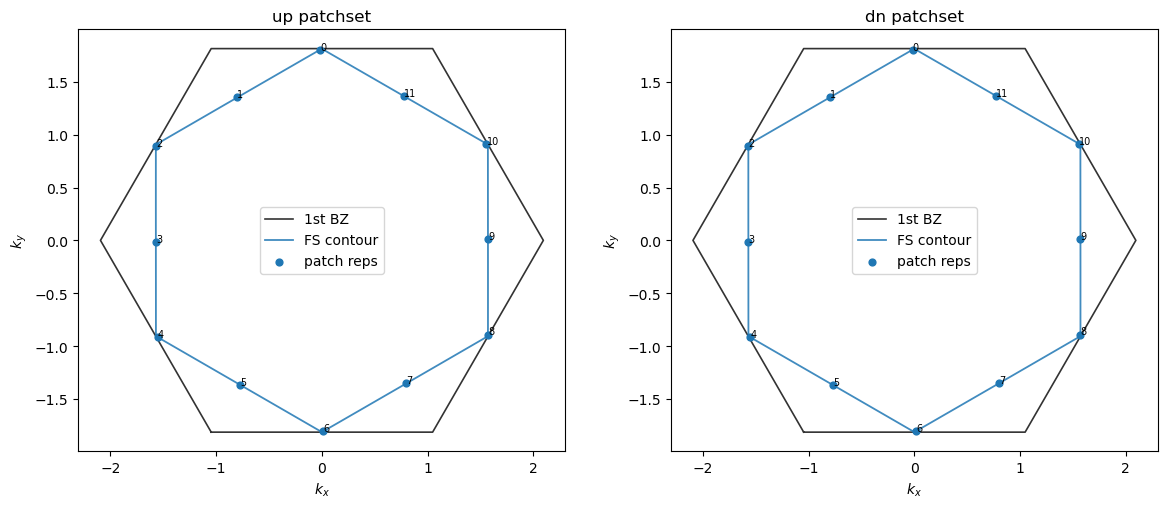

max |k_up - k_dn| = 0.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_patchset(patchset_up, ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("up patchset")

plot_patchset(patchset_dn, ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("dn patchset")

plt.tight_layout()
plt.show()

print("max |k_up - k_dn| =", np.max(np.linalg.norm(patchset_up.patch_k - patchset_dn.patch_k, axis=1)))

# Bare Interaction

In [6]:
t0 = time.perf_counter()

hint = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
bare_gamma = BareVertexFromInteraction(patchsets=patchsets, interaction=hint)

t1 = time.perf_counter()

print(f"Bare interaction / bare gamma build time: {t1 - t0:.3f} s")
print("Norb =", hint.Norb)

Bare interaction / bare gamma build time: 0.000 s
Norb = 3


In [7]:
samples = [
    (0, "up", 1, "dn", 2, "up", 3, "dn"),
    (0, "up", 1, "up", 2, "up", 3, "up"),
    (0, "dn", 1, "up", 2, "dn", 3, "up"),
]

for args in samples:
    val = bare_gamma(*args)
    print(args, "->", val)

(0, 'up', 1, 'dn', 2, 'up', 3, 'dn') -> (6.120374525515367e-16+0j)
(0, 'up', 1, 'up', 2, 'up', 3, 'up') -> (5.955701590059886e-16+0j)
(0, 'dn', 1, 'up', 2, 'dn', 3, 'up') -> (6.120374525515367e-16+0j)


# Order Diagnoser and Solver

In [8]:
diagnoser = KagomeOrderDiagnoser(patchsets_by_spin=patchsets)

solver = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=bare_gamma,
    diagnoser=diagnoser,

    T_start=0.40,
    T_stop=0.02,
    n_steps=24,
    temperature_grid="log",

    nfreq=128,
    include_explicit_T_prefactor=True,

    max_relative_update=0.15,
    min_substep_fraction=1.0 / 128.0,

    channel_divergence_threshold=1e3,
    eigenvalue_threshold=1e2,

    diagnose_every=2,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
)

print("Solver built.")
print("spin blocks =", solver.spin_blocks)
print("NQ_pp  =", len(solver.pp_grid.q_list))
print("NQ_phd =", len(solver.phd_grid.q_list))
print("NQ_phc =", len(solver.phc_grid.q_list))

Solver built.
spin blocks = [('up', 'up', 'up', 'up'), ('dn', 'dn', 'dn', 'dn'), ('up', 'dn', 'up', 'dn'), ('up', 'dn', 'dn', 'up'), ('dn', 'up', 'up', 'dn'), ('dn', 'up', 'dn', 'up')]
NQ_pp  = 79
NQ_phd = 133
NQ_phc = 133


## one loop kernel and diagnosis

In [11]:
T_probe = 0.40

t0 = time.perf_counter()
rhs_pp, rhs_phd, rhs_phc = solver.compute_channel_rhs(T_probe)
t1 = time.perf_counter()

def store_norm(store):
    vals = [np.max(np.abs(v)) for v in store.values() if getattr(v, "size", 0)]
    return max(vals) if vals else 0.0

print(f"RHS total time @ T={T_probe:.3f}: {t1 - t0:.3f} s")
print("||rhs_pp||_max  =", store_norm(rhs_pp))
print("||rhs_phd||_max =", store_norm(rhs_phd))
print("||rhs_phc||_max =", store_norm(rhs_phc))
print("n_pp blocks  =", len(rhs_pp))
print("n_phd blocks =", len(rhs_phd))
print("n_phc blocks =", len(rhs_phc))

RHS total time @ T=0.400: 153.524 s
||rhs_pp||_max  = 3123.1276596710672
||rhs_phd||_max = 17470.366964159504
||rhs_phc||_max = 17470.366964159504
n_pp blocks  = 474
n_phd blocks = 798
n_phc blocks = 798


pp ('up', 'up', 'up', 'up', 47) 3123.1276596710672


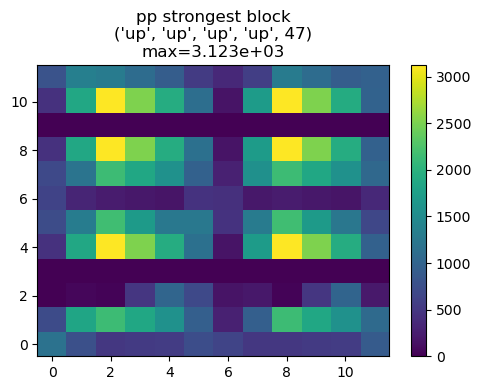

phd ('up', 'up', 'up', 'up', 0) 17470.366964159504


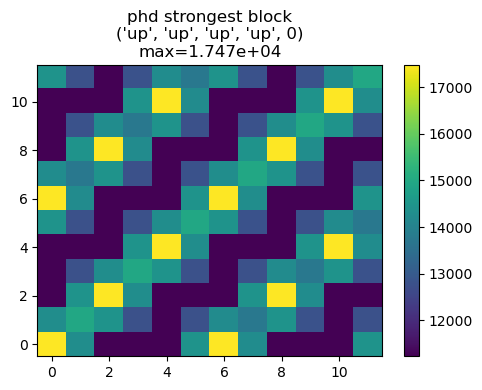

phc ('up', 'up', 'up', 'up', 0) 17470.366964159504


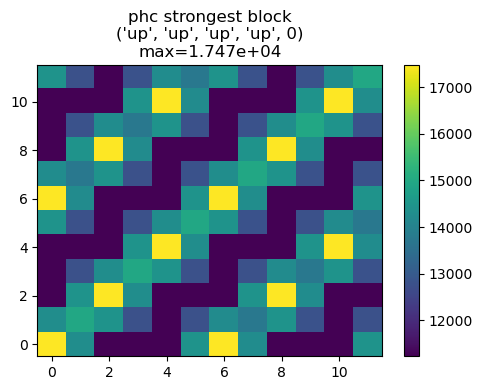

In [12]:
def strongest_block(store):
    best_key = None
    best_val = -1.0
    best_mat = None
    for key, mat in store.items():
        val = float(np.max(np.abs(mat)))
        if val > best_val:
            best_key = key
            best_val = val
            best_mat = mat
    return best_key, best_mat, best_val

for name, store in [("pp", rhs_pp), ("phd", rhs_phd), ("phc", rhs_phc)]:
    key, mat, val = strongest_block(store)
    print(name, key, val)

    plt.figure(figsize=(5,4))
    plt.imshow(np.abs(mat), origin="lower", aspect="auto")
    plt.colorbar()
    plt.title(f"{name} strongest block\n{key}\nmax={val:.3e}")
    plt.tight_layout()
    plt.show()

In [13]:
def show_top_q_vectors(grid, top_list, name):
    print(f"\n{name}:")
    for iq, val in top_list:
        Q = np.asarray(grid.q_list[iq], dtype=float)
        print(f"iq={iq:4d}, val={val:.6f}, Q={Q}")

show_top_q_vectors(solver.pp_grid, top_qs(rhs_pp, topk=15), "Top pp Q vectors")
show_top_q_vectors(solver.phd_grid, top_qs(rhs_phd, topk=15), "Top phd Q vectors")
show_top_q_vectors(solver.phc_grid, top_qs(rhs_phc, topk=15), "Top phc Q vectors")


Top pp Q vectors:
iq=  47, val=3123.127660, Q=[ 0.01649785 -1.80680523]
iq=   5, val=3122.473563, Q=[-1.57100132  0.88773125]
iq=  28, val=3100.427399, Q=[-1.55616174 -0.91744496]
iq=  62, val=3043.024233, Q=[ 1.57103442 -0.89013858]
iq=  32, val=3041.475679, Q=[-0.0143965   1.80311663]
iq=   9, val=2989.023971, Q=[1.55409349 0.91377546]
iq=  22, val=2498.106738, Q=[0.75613295 2.26697657]
iq=  27, val=2497.303668, Q=[-2.34142967 -0.48096887]
iq=  72, val=2495.859091, Q=[2.34354464 0.47727241]
iq=  46, val=2495.592077, Q=[-0.75614657 -2.26941087]
iq=   4, val=2449.897585, Q=[-1.58749917  1.78704705]
iq=  61, val=2448.175400, Q=[ 1.58543092 -1.79068331]
iq=  10, val=2357.165262, Q=[1.55409349 1.81882275]
iq=  67, val=2357.151657, Q=[ 2.35455174 -0.43777464]
iq=  54, val=2284.435242, Q=[ 0.80016298 -2.2592545 ]

Top phd Q vectors:
iq=   0, val=17470.366964, Q=[0. 0.]
iq=  30, val=17469.619449, Q=[ 3.14159265 -1.77828563]
iq=  91, val=17468.803739, Q=[-3.14159265  1.77828563]
iq= 115, val

In [15]:
# strongest candidate Qs from your 12-patch run
iq_phc_q0 = 0
iq_phd_M  = 30
iq_pp_M   = 5

for name, grid, iq in [
    ("phc_Q0", solver.phc_grid, iq_phc_q0),
    ("phd_M",  solver.phd_grid, iq_phd_M),
    ("pp_M",   solver.pp_grid,  iq_pp_M),
]:
    Q = np.asarray(grid.q_list[iq], dtype=float)
    print(f"\n=== {name} ===")
    print("iq =", iq, "Q =", Q)

    t0 = time.perf_counter()
    kernels = solver.build_diagnosis_kernel_dict(Q)
    t1 = time.perf_counter()
    print(f"build_diagnosis_kernel_dict time: {t1 - t0:.3f} s")
    print("available kernels:", list(kernels.keys()))

    for kname, ker in kernels.items():
        vals, vecs = ker.eig(sort_by="abs")
        lead = np.abs(vals[0]) if len(vals) else 0.0
        print(f"  {kname:20s} leading |eig| = {lead:.6e}")

        d = diagnoser.diagnose_kernel(ker, sort_by="abs")
        print("    paper_label   =", d.paper_label)
        print("    coarse_label  =", d.coarse_label)
        print("    top_template  =", d.top_template_name)


=== phc_Q0 ===
iq = 0 Q = [0. 0.]
build_diagnosis_kernel_dict time: 0.516 s
available kernels: ['pp_ud_to_ud', 'pp_ud_to_du', 'pp_du_to_ud', 'pp_du_to_du', 'pp_singlet_sz0', 'pp_triplet_sz0', 'pp_triplet_uu', 'phd_uu', 'phc_uu', 'pp_triplet_dd', 'phd_dd', 'phc_dd', 'ph_charge_longitudinal', 'ph_spin_longitudinal']
  pp_ud_to_ud          leading |eig| = 2.000438e+01
    paper_label   = unclassified
    coarse_label  = pp_odd
    top_template  = fSC_AC
  pp_ud_to_du          leading |eig| = 2.000438e+01
    paper_label   = unclassified
    coarse_label  = pp_odd
    top_template  = fSC_AC
  pp_du_to_ud          leading |eig| = 2.000438e+01
    paper_label   = unclassified
    coarse_label  = pp_odd
    top_template  = fSC_AC
  pp_du_to_du          leading |eig| = 2.000438e+01
    paper_label   = unclassified
    coarse_label  = pp_odd
    top_template  = fSC_AC
  pp_singlet_sz0       leading |eig| = 3.627493e-04
    paper_label   = unclassified
    coarse_label  = pp_even
    top_templa

## flow

In [17]:
import numpy as np
import time

def selective_diagnosis_snapshot(solver, diagnoser, q_targets):
    """
    q_targets: list of tuples
        [
          ("phc_Q0", solver.phc_grid, 0),
          ("phd_M",  solver.phd_grid, 30),
          ("pp_M",   solver.pp_grid, 76),
        ]
    """
    out = {}

    for tag, grid, iq in q_targets:
        Q = np.asarray(grid.q_list[iq], dtype=float)
        kernels = solver.build_diagnosis_kernel_dict(Q)

        tag_info = {
            "iq": iq,
            "Q": Q.copy(),
            "kernels": {}
        }

        for kname, ker in kernels.items():
            vals, _ = ker.eig(sort_by="abs")
            lead_eval = float(np.abs(vals[0])) if len(vals) else 0.0

            d = diagnoser.diagnose_kernel(ker, sort_by="abs")
            tag_info["kernels"][kname] = {
                "leading_eval": lead_eval,
                "paper_label": d.paper_label,
                "coarse_label": d.coarse_label,
                "top_template": d.top_template_name,
            }

        out[tag] = tag_info

    return out

def apply_manual_euler_step(solver, rhs_pp, rhs_phd, rhs_phc, dT):
    for key in solver.state.pp_corr:
        solver.state.pp_corr[key] = solver.state.pp_corr[key] + dT * rhs_pp[key]

    for key in solver.state.phd_corr:
        solver.state.phd_corr[key] = solver.state.phd_corr[key] + dT * rhs_phd[key]

    for key in solver.state.phc_corr:
        solver.state.phc_corr[key] = solver.state.phc_corr[key] + dT * rhs_phc[key]

    solver.state.T = float(solver.state.T + dT)

def inspect_manual_step(solver, T_old, dT):
    rhs_pp, rhs_phd, rhs_phc = solver.compute_channel_rhs(T_old)
    rhs_norm = solver._rhs_norm(rhs_pp, rhs_phd, rhs_phc)
    state_norm = solver.state.channel_norm()
    effective_norm = max(state_norm, solver.bare_vertex_norm, 1e-14)
    rel_update = abs(dT) * rhs_norm / effective_norm

    return {
        "rhs_pp": rhs_pp,
        "rhs_phd": rhs_phd,
        "rhs_phc": rhs_phc,
        "rhs_norm": rhs_norm,
        "state_norm": state_norm,
        "effective_norm": effective_norm,
        "rel_update": rel_update,
    }

In [18]:
solver_manual = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=bare_gamma,
    diagnoser=diagnoser,

    T_start=0.40,
    T_stop=0.10,
    n_steps=6,   # 这里只是占位，不再真正用它的 path 做 step
    temperature_grid="log",

    nfreq=128,
    include_explicit_T_prefactor=True,

    max_relative_update=0.15,
    min_substep_fraction=1.0/128.0,

    channel_divergence_threshold=1e3,
    eigenvalue_threshold=1e2,

    diagnose_every=1,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
)

In [19]:
def inspect_manual_step(solver, T_old, dT):
    rhs_pp, rhs_phd, rhs_phc = solver.compute_channel_rhs(T_old)
    rhs_norm = solver._rhs_norm(rhs_pp, rhs_phd, rhs_phc)
    state_norm = solver.state.channel_norm()
    effective_norm = max(state_norm, solver.bare_vertex_norm, 1e-14)
    rel_update = abs(dT) * rhs_norm / effective_norm

    return {
        "rhs_pp": rhs_pp,
        "rhs_phd": rhs_phd,
        "rhs_phc": rhs_phc,
        "rhs_norm": rhs_norm,
        "state_norm": state_norm,
        "effective_norm": effective_norm,
        "rel_update": rel_update,
    }

In [20]:
q_targets = [
    ("phc_Q0", solver_manual.phc_grid, 0),   # Q = 0
    ("phd_M",  solver_manual.phd_grid, 30),  # strongest M in phd
    ("pp_M",   solver_manual.pp_grid, 76),   # strongest M in pp
]

In [26]:
manual_history = []

T = 0.4000
dT_manual = -1e-4
n_manual_steps = 20

for istep in range(n_manual_steps):
    print(f"\n=== manual step {istep} ===")
    print(f"T = {T:.6f}")

    t0 = time.perf_counter()
    info = inspect_manual_step(solver_manual, T, dT_manual)
    t1 = time.perf_counter()

    print(f"RHS time       = {t1 - t0:.3f} s")
    print(f"rhs_norm       = {info['rhs_norm']:.6e}")
    print(f"state_norm     = {info['state_norm']:.6e}")
    print(f"effective_norm = {info['effective_norm']:.6e}")
    print(f"rel_update     = {info['rel_update']:.6e}")

    # 保险：如果 rel_update 过大，直接停
    if info["rel_update"] > 0.15:
        print("rel_update too large, stopping.")
        break

    # 手动更新
    apply_manual_euler_step(
        solver_manual,
        info["rhs_pp"], info["rhs_phd"], info["rhs_phc"],
        dT_manual
    )
    T = T + dT_manual

    # 更新后做 selective diagnosis
    t2 = time.perf_counter()
    diag = selective_diagnosis_snapshot(solver_manual, diagnoser, q_targets)
    t3 = time.perf_counter()

    # print(f"diagnosis time = {t3 - t2:.3f} s")
    # print(f"new T          = {T:.6f}")
    # print(f"new channel norm = {solver_manual.state.channel_norm():.6e}")

    # 存结果
    row = {
        "step": istep,
        "T": T,
        "rhs_norm": float(info["rhs_norm"]),
        "state_norm_before": float(info["state_norm"]),
        "effective_norm": float(info["effective_norm"]),
        "rel_update": float(info["rel_update"]),
        "channel_norm_after": float(solver_manual.state.channel_norm()),
        "diagnosis": diag,
    }
    manual_history.append(row)


=== manual step 0 ===
T = 0.400000
RHS time       = 149.687 s
rhs_norm       = 1.747037e+04
state_norm     = 0.000000e+00
effective_norm = 1.999729e+01
rel_update     = 8.736366e-02

=== manual step 1 ===
T = 0.399900
RHS time       = 158.001 s
rhs_norm       = 1.978325e+04
state_norm     = 1.747037e+00
effective_norm = 1.999729e+01
rel_update     = 9.892966e-02

=== manual step 2 ===
T = 0.399800
RHS time       = 158.827 s
rhs_norm       = 2.298444e+04
state_norm     = 3.725287e+00
effective_norm = 1.999729e+01
rel_update     = 1.149377e-01

=== manual step 3 ===
T = 0.399700
RHS time       = 137.837 s
rhs_norm       = 2.744469e+04
state_norm     = 6.023731e+00
effective_norm = 1.999729e+01
rel_update     = 1.372420e-01

=== manual step 4 ===
T = 0.399600
RHS time       = 138.117 s
rhs_norm       = 3.376583e+04
state_norm     = 8.768200e+00
effective_norm = 1.999729e+01
rel_update     = 1.688520e-01
rel_update too large, stopping.


In [35]:
def extract_metric(history, tag, kernel_name, field="leading_eval"):
    vals = []
    for row in history:
        try:
            vals.append(row["diagnosis"][tag]["kernels"][kernel_name][field])
        except KeyError:
            vals.append(np.nan)
    return np.array(vals, dtype=float)

def extract_template(history, tag, kernel_name):
    vals = []
    for row in history:
        try:
            vals.append(row["diagnosis"][tag]["kernels"][kernel_name]["top_template"])
        except KeyError:
            vals.append(None)
    return vals

Ts = np.array([row["T"] for row in manual_history[:4]], dtype=float)
rhs_norms = np.array([row["rhs_norm"] for row in manual_history[:4]], dtype=float)
channel_norms = np.array([row["channel_norm_after"] for row in manual_history[:4]], dtype=float)
rel_updates = np.array([row["rel_update"] for row in manual_history[:4]], dtype=float)

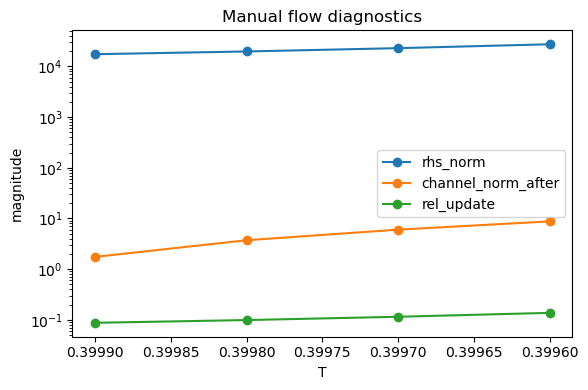

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(Ts, rhs_norms, marker="o", label="rhs_norm")
plt.plot(Ts, channel_norms, marker="o", label="channel_norm_after")
plt.plot(Ts, rel_updates, marker="o", label="rel_update")
plt.gca().invert_xaxis()
plt.yscale("log")
plt.xlabel("T")
plt.ylabel("magnitude")
plt.title("Manual flow diagnostics")
plt.legend()
plt.tight_layout()
plt.show()

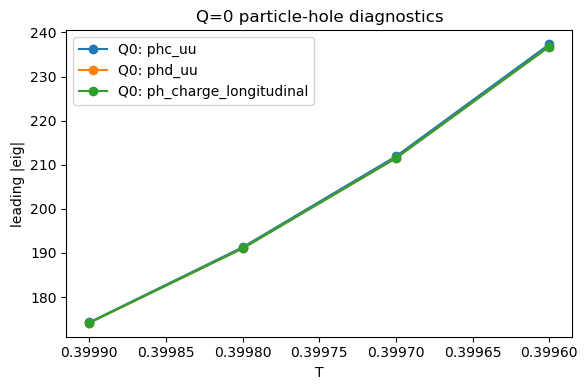

In [37]:
phc_q0_uu = extract_metric(manual_history[:4], "phc_Q0", "phc_uu")
phd_q0_uu = extract_metric(manual_history[:4], "phc_Q0", "phd_uu")
phc_q0_charge = extract_metric(manual_history[:4], "phc_Q0", "ph_charge_longitudinal")

plt.figure(figsize=(6,4))
plt.plot(Ts, phc_q0_uu, marker="o", label="Q0: phc_uu")
plt.plot(Ts, phd_q0_uu, marker="o", label="Q0: phd_uu")
plt.plot(Ts, phc_q0_charge, marker="o", label="Q0: ph_charge_longitudinal")
plt.gca().invert_xaxis()
plt.xlabel("T")
plt.ylabel("leading |eig|")
plt.title("Q=0 particle-hole diagnostics")
plt.legend()
plt.tight_layout()
plt.show()

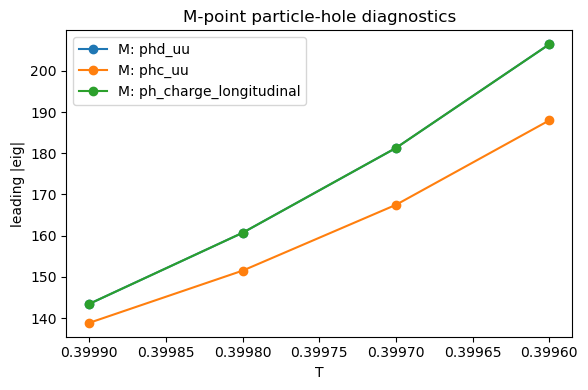

In [38]:
phd_M_uu = extract_metric(manual_history[:4], "phd_M", "phd_uu")
phc_M_uu = extract_metric(manual_history[:4], "phd_M", "phc_uu")
ph_M_charge = extract_metric(manual_history[:4], "phd_M", "ph_charge_longitudinal")

plt.figure(figsize=(6,4))
plt.plot(Ts, phd_M_uu, marker="o", label="M: phd_uu")
plt.plot(Ts, phc_M_uu, marker="o", label="M: phc_uu")
plt.plot(Ts, ph_M_charge, marker="o", label="M: ph_charge_longitudinal")
plt.gca().invert_xaxis()
plt.xlabel("T")
plt.ylabel("leading |eig|")
plt.title("M-point particle-hole diagnostics")
plt.legend()
plt.tight_layout()
plt.show()

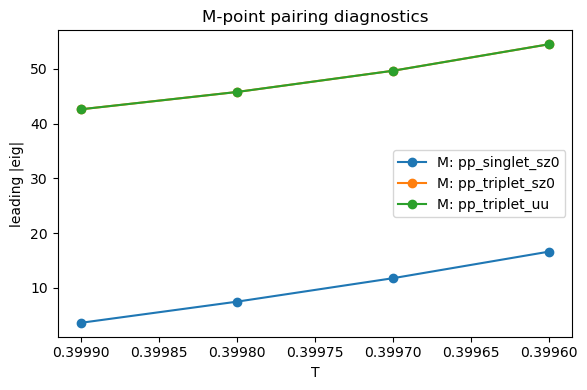

In [39]:
ppM_singlet = extract_metric(manual_history[:4], "pp_M", "pp_singlet_sz0")
ppM_triplet0 = extract_metric(manual_history[:4], "pp_M", "pp_triplet_sz0")
ppM_tripletuu = extract_metric(manual_history[:4], "pp_M", "pp_triplet_uu")

plt.figure(figsize=(6,4))
plt.plot(Ts, ppM_singlet, marker="o", label="M: pp_singlet_sz0")
plt.plot(Ts, ppM_triplet0, marker="o", label="M: pp_triplet_sz0")
plt.plot(Ts, ppM_tripletuu, marker="o", label="M: pp_triplet_uu")
plt.gca().invert_xaxis()
plt.xlabel("T")
plt.ylabel("leading |eig|")
plt.title("M-point pairing diagnostics")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
import numpy as np

def kernel_fm_pi_components(diagnoser, kernel, sort_by="abs"):
    """
    Extract FM-vs-PI template information for one kernel.
    PI is treated as the two-dimensional d-wave subspace:
        PI_score = score(PI_dx2y2) + score(PI_dxy)
    """
    # leading eig
    vals, _ = kernel.eig(sort_by=sort_by)
    leading_eval = float(np.abs(vals[0])) if len(vals) else 0.0

    # recognizer info
    analyses = diagnoser.recognizer.analyze_kernel(kernel, n_groups=1, sort_by=sort_by)
    if not analyses:
        return {
            "leading_eval": leading_eval,
            "dominant_label": None,
            "subspace_dim": 0,
            "FM_score": 0.0,
            "PI_dx2y2": 0.0,
            "PI_dxy": 0.0,
            "PI_score": 0.0,
            "PI_max": 0.0,
            "top_template": None,
            "top_template_score": 0.0,
        }

    mode = analyses[0]

    # full paper-template scores
    d = diagnoser.diagnose_kernel(kernel, sort_by=sort_by)
    score_map = {ts.name: float(ts.score) for ts in d.template_scores}

    fm_score = score_map.get("FM_constant", 0.0)
    pi_dx2y2 = score_map.get("PI_dx2y2", 0.0)
    pi_dxy = score_map.get("PI_dxy", 0.0)

    return {
        "leading_eval": leading_eval,
        "dominant_label": mode.dominant_label,
        "subspace_dim": int(mode.subspace_dim),
        "FM_score": fm_score,
        "PI_dx2y2": pi_dx2y2,
        "PI_dxy": pi_dxy,
        "PI_score": pi_dx2y2 + pi_dxy,   # treat PI as degenerate d-wave subspace
        "PI_max": max(pi_dx2y2, pi_dxy),
        "top_template": d.top_template_name,
        "top_template_score": float(d.top_template_score),
        "paper_label": d.paper_label,
        "coarse_label": d.coarse_label,
    }

def q0_fm_pi_snapshot(solver, diagnoser, iq_q0=0):
    """
    Collect FM/PI-resolved diagnostics at Q=0 only.
    """
    Q0 = np.asarray(solver.phc_grid.q_list[iq_q0], dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q0)

    out = {
        "Q": Q0.copy(),
        "kernels": {}
    }

    for kname in ["ph_charge_longitudinal", "phd_uu", "phc_uu"]:
        if kname in kernels:
            out["kernels"][kname] = kernel_fm_pi_components(diagnoser, kernels[kname], sort_by="abs")

    return out

def run_manual_flow_fm_pi(
    solver,
    diagnoser,
    *,
    T0=0.4000,
    dT_manual=-2e-4,
    n_steps=10,
    rel_update_stop=0.15,
):
    history = []
    T = float(T0)

    for istep in range(n_steps):
        print(f"\n=== manual step {istep} ===")
        print(f"T = {T:.6f}")

        info = inspect_manual_step(solver, T, dT_manual)
        print(f"rhs_norm       = {info['rhs_norm']:.6e}")
        print(f"state_norm     = {info['state_norm']:.6e}")
        print(f"effective_norm = {info['effective_norm']:.6e}")
        print(f"rel_update     = {info['rel_update']:.6e}")

        if info["rel_update"] > rel_update_stop:
            print("rel_update too large, stopping.")
            break

        # manual Euler
        apply_manual_euler_step(
            solver,
            info["rhs_pp"], info["rhs_phd"], info["rhs_phc"],
            dT_manual
        )
        T = T + dT_manual

        # Q=0 FM/PI diagnosis after update
        q0_diag = q0_fm_pi_snapshot(solver, diagnoser, iq_q0=0)

        row = {
            "step": istep,
            "T": T,
            "rhs_norm": float(info["rhs_norm"]),
            "state_norm_before": float(info["state_norm"]),
            "effective_norm": float(info["effective_norm"]),
            "rel_update": float(info["rel_update"]),
            "channel_norm_after": float(solver.state.channel_norm()),
            "q0_diag": q0_diag,
        }
        history.append(row)

    return history

import matplotlib.pyplot as plt
import numpy as np

def extract_q0_component(history, kernel_name, field):
    vals = []
    for row in history:
        vals.append(row["q0_diag"]["kernels"][kernel_name][field])
    return np.array(vals, dtype=float)

def plot_fm_vs_pi(history, kernel_name="ph_charge_longitudinal"):
    Ts = np.array([row["T"] for row in history], dtype=float)

    fm = extract_q0_component(history, kernel_name, "FM_score")
    pi = extract_q0_component(history, kernel_name, "PI_score")
    pi_dx2y2 = extract_q0_component(history, kernel_name, "PI_dx2y2")
    pi_dxy = extract_q0_component(history, kernel_name, "PI_dxy")
    lead = extract_q0_component(history, kernel_name, "leading_eval")

    total = fm + pi
    fm_frac = np.divide(fm, total, out=np.zeros_like(fm), where=total > 0)
    pi_frac = np.divide(pi, total, out=np.zeros_like(pi), where=total > 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # absolute template scores
    axes[0].plot(Ts, fm, marker="o", label="FM_constant score")
    axes[0].plot(Ts, pi, marker="o", label="PI total score = dx2y2 + dxy")
    axes[0].plot(Ts, pi_dx2y2, marker="o", linestyle="--", label="PI_dx2y2")
    axes[0].plot(Ts, pi_dxy, marker="o", linestyle="--", label="PI_dxy")
    axes[0].plot(Ts, lead, marker="o", linestyle=":", label="leading |eig|")
    axes[0].invert_xaxis()
    axes[0].set_xlabel("T")
    axes[0].set_ylabel("score / eig")
    axes[0].set_title(f"{kernel_name}: FM vs PI template scores")
    axes[0].legend()

    # relative fractions
    axes[1].plot(Ts, fm_frac, marker="o", label="FM fraction")
    axes[1].plot(Ts, pi_frac, marker="o", label="PI fraction")
    axes[1].invert_xaxis()
    axes[1].set_xlabel("T")
    axes[1].set_ylabel("fraction within FM+PI")
    axes[1].set_title(f"{kernel_name}: FM vs PI fractions")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def print_q0_fm_pi_summary(history, kernel_name="ph_charge_longitudinal"):
    Ts = np.array([row["T"] for row in history], dtype=float)

    print(f"\n=== {kernel_name} FM/PI summary ===")
    for i, row in enumerate(history):
        data = row["q0_diag"]["kernels"][kernel_name]
        print(
            f"step={row['step']:2d}, T={row['T']:.6f}, "
            f"lead={data['leading_eval']:.6e}, "
            f"FM={data['FM_score']:.4f}, "
            f"PI_total={data['PI_score']:.4f}, "
            f"(dx2y2={data['PI_dx2y2']:.4f}, dxy={data['PI_dxy']:.4f}), "
            f"subspace_dim={data['subspace_dim']}, "
            f"dominant_label={data['dominant_label']}, "
            f"top_template={data['top_template']}"
        )


=== manual step 0 ===
T = 0.400000
rhs_norm       = 1.747037e+04
state_norm     = 0.000000e+00
effective_norm = 1.999729e+01
rel_update     = 1.747273e-01

=== manual step 1 ===
T = 0.399800
rhs_norm       = 2.238339e+04
state_norm     = 3.494073e+00
effective_norm = 1.999729e+01
rel_update     = 2.238642e-01

=== manual step 2 ===
T = 0.399600
rhs_norm       = 3.139075e+04
state_norm     = 7.970602e+00
effective_norm = 1.999729e+01
rel_update     = 3.139500e-01

=== manual step 3 ===
T = 0.399400
rhs_norm       = 4.872108e+04
state_norm     = 1.424875e+01
effective_norm = 1.999729e+01
rel_update     = 4.872767e-01

=== manual step 4 ===
T = 0.399200
rhs_norm       = 8.610625e+04
state_norm     = 2.399297e+01
effective_norm = 2.399297e+01
rel_update     = 7.177624e-01

=== manual step 5 ===
T = 0.399000
rhs_norm       = 1.849389e+05
state_norm     = 4.116153e+01
effective_norm = 4.116153e+01
rel_update     = 8.986010e-01

=== manual step 6 ===
T = 0.398800
rhs_norm       = 5.271912e+0

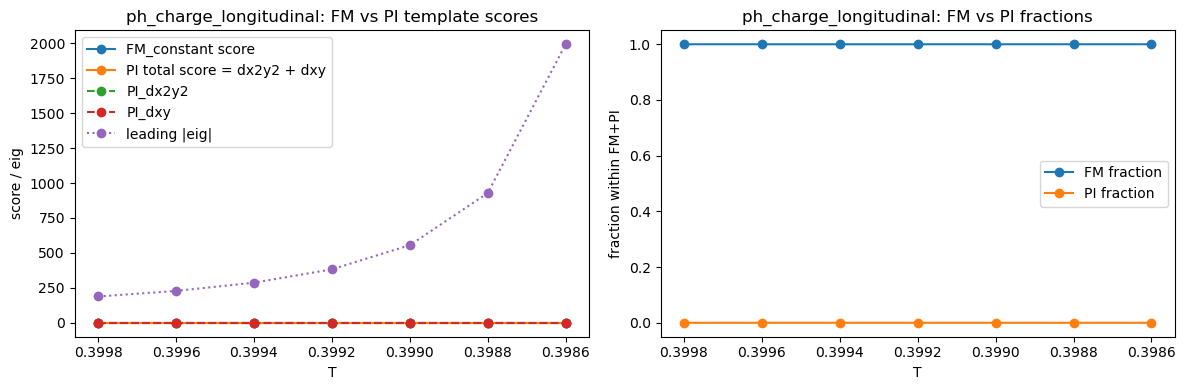

In [ ]:
# 1) 重新建一个干净 solver_manual（U=6, V=0.2 那组）
solver_manual = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=bare_gamma,
    diagnoser=diagnoser,

    T_start=0.40,
    T_stop=0.10,
    n_steps=6,   # 这里只是占位，不再真正用它的 path 做 step
    temperature_grid="log",

    nfreq=128,
    include_explicit_T_prefactor=True,

    max_relative_update=1.5,
    min_substep_fraction=1,

    channel_divergence_threshold=1e3,
    eigenvalue_threshold=1e2,

    diagnose_every=1,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
)

# 2) 跑 FM/PI-aware manual flow
history_fm_pi = run_manual_flow_fm_pi(
    solver_manual,
    diagnoser,
    T0=0.4000,
    dT_manual=-2e-4,
    n_steps=20,
    rel_update_stop=1.5,
)

# 3) 画图
plot_fm_vs_pi(history_fm_pi, kernel_name="ph_charge_longitudinal")
plot_fm_vs_pi(history_fm_pi, kernel_name="phd_uu")
plot_fm_vs_pi(history_fm_pi, kernel_name="phc_uu")

# 4) 打印 summary
print_q0_fm_pi_summary(history_fm_pi, kernel_name="ph_charge_longitudinal")
print_q0_fm_pi_summary(history_fm_pi, kernel_name="phd_uu")
print_q0_fm_pi_summary(history_fm_pi, kernel_name="phc_uu")